**Objective**

To analyze global glacier mass balance trends and identify regions most vulnerable to accelerated glacier melting. The study will:

Quantify the rate of glacier melting globally, across countries and regions.

Compare India’s glacier melting trends with global patterns.

Identify neighboring or climatically similar glaciers to India (e.g., High Mountain Asia, Himalayas, Karakoram) and analyze their melting rates.


Importing all the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading indian dataset

In [2]:
df_india=pd.read_excel("chhota shigr.xlsx")
df_india.head()


,Year,Glacier area,"Ban,cal","Error of Ban,cal","Bat,cal",db/dz,ELAcal,AARcal,Difference
0,NaN,(km2),(mw.e.a-1),(mw.e.a-1),(mw.e.a-1),(mw.e. (100)−1 a−1),(ma.s.l.),(%),"Ban,cal-Bat,cal"
1,2002/2003,15.66,−1.10,0.21,−1.34,0.7,5145,33,0.24
2,2003/2004,15.64,−1.14,0.19,−1.14,0.71,5156,32,0.01
3,2004/2005,15.63,0.49,0.19,0.24,0.59,4911,67,0.26
4,2005/2006,15.61,−1.14,0.19,−1.33,0.71,5157,32,0.19


In [3]:
df_india.info()

df_india.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Year              23 non-null     object
 1   Glacier area      24 non-null     object
 2   Ban,cal           24 non-null     object
 3   Error of Ban,cal  24 non-null     object
 4   Bat,cal           24 non-null     object
 5   db/dz             24 non-null     object
 6   ELAcal            24 non-null     object
 7   AARcal            24 non-null     object
 8   Difference        24 non-null     object
dtypes: object(9)
memory usage: 1.8+ KB


,0
Year,1
Glacier area,0
"Ban,cal",0
"Error of Ban,cal",0
"Bat,cal",0
db/dz,0
ELAcal,0
AARcal,0
Difference,0


In [4]:
 df_india.drop(index=0,inplace=True) # dropping units row

In [5]:
df_india = df_india.iloc[:-2, :] #removing last two rows containing mean and std

In [6]:
df_india.rename(columns={
    'Year': 'Year',
    'Glacier area': 'Glacier_area',
    'ELAcal': 'ELA',
    'AARcal': 'AAR',
    'Ban,cal': 'Annual_Balance',
    'Bat,cal': 'Annual_balance_model2',
    'Difference': 'Balance_difference',
    'Error of Ban,cal': 'Annual_balance_error',
    'db/dz': 'Balance_gradient'
}, inplace=True)


In [7]:
df_india['Year']=df_india['Year'].astype(str).str.split('/').str[-1].astype(int)

In [8]:
for col in df_india.columns[1:]:
    # Replace the non-standard minus sign '−' with a standard hyphen '-'
    df_india[col] = df_india[col].astype(str).str.replace('−', '-')
    df_india[col] = pd.to_numeric(df_india[col], errors="coerce")

In [9]:
df_india = df_india.interpolate(method="linear")

In [10]:
df_india = df_india.dropna(how="all")

In [11]:
df_india = df_india.reset_index(drop=True)

In [12]:
df_india.isnull().sum()
df_india.head(21)



,Year,Glacier_area,Annual_Balance,Annual_balance_error,Annual_balance_model2,Balance_gradient,ELA,AAR,Balance_difference
0,2003,15.66,-1.10,0.21,-1.34,0.70,5145,33,0.24
1,2004,15.64,-1.14,0.19,-1.14,0.71,5156,32,0.01
2,2005,15.63,0.49,0.19,0.24,0.59,4911,67,0.26
3,2006,15.61,-1.14,0.19,-1.33,0.71,5157,32,0.19
4,2007,15.59,-0.91,0.19,-0.90,0.69,5128,36,-0.01
5,2008,15.57,-0.67,0.19,-0.84,0.67,5096,40,0.17
6,2009,15.56,0.29,0.19,0.22,0.60,4942,63,0.07
7,2010,15.54,0.43,0.19,0.42,0.59,4921,65,0.01
8,2011,15.52,-0.16,0.19,0.17,0.64,5022,50,-0.33
9,2012,15.50,-0.42,0.19,-0.36,0.66,5061,44,-0.06


📊 Descriptive Statistics


/tmp/ipython-input-2245772336.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


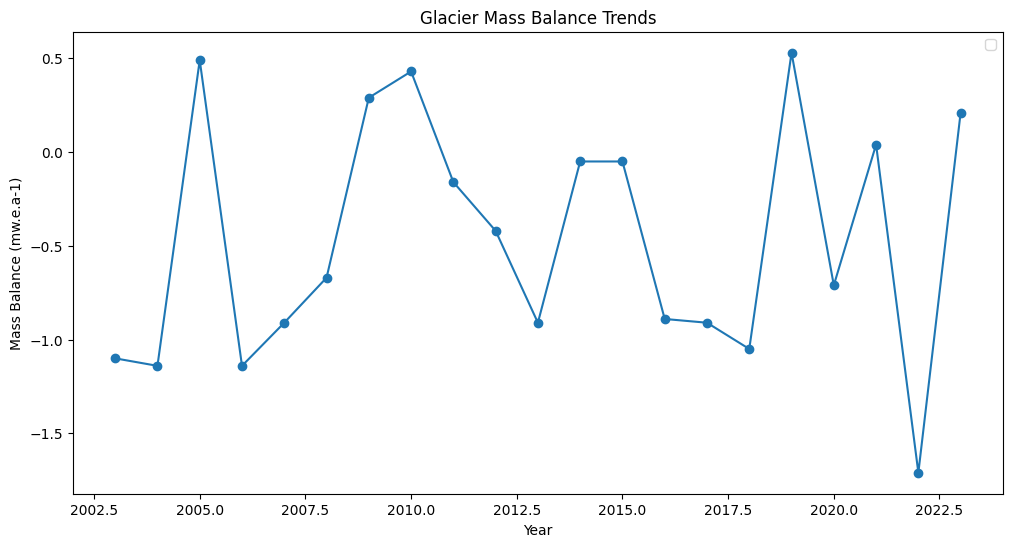

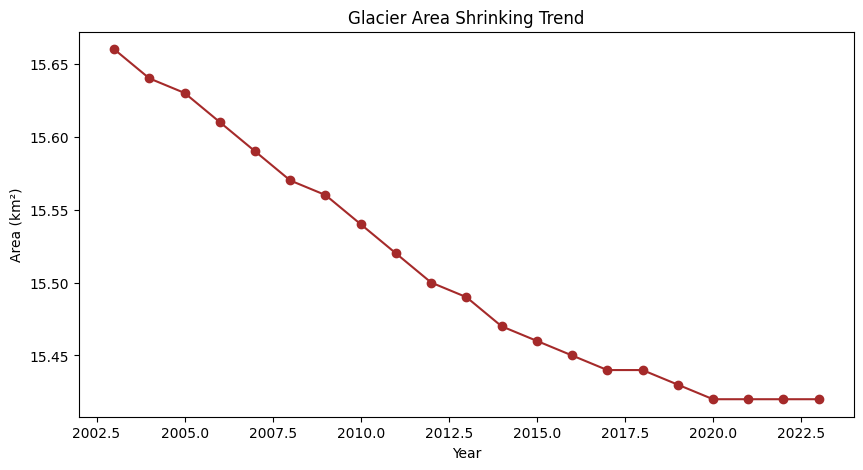

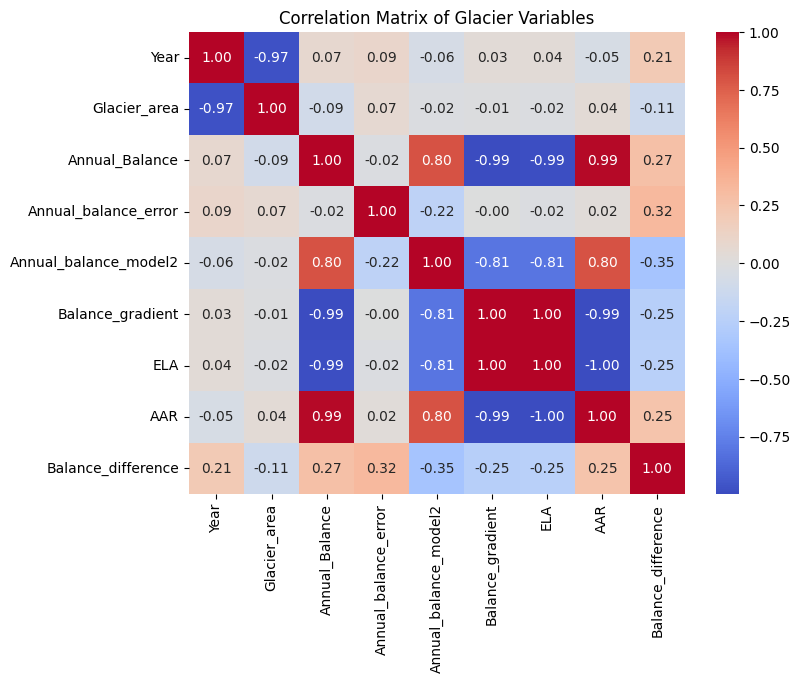

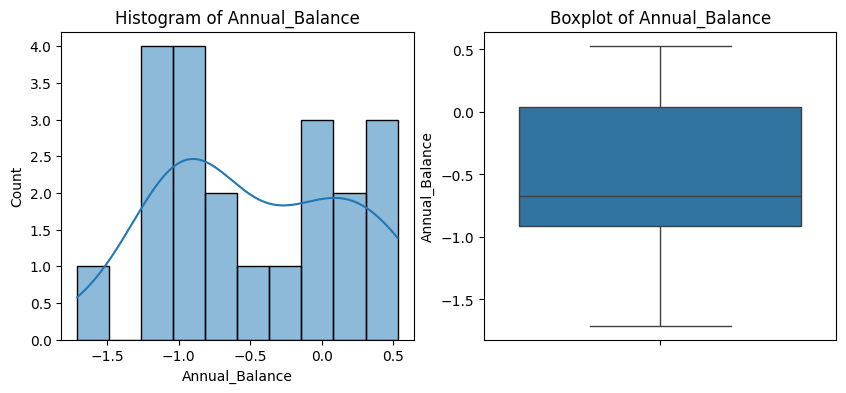

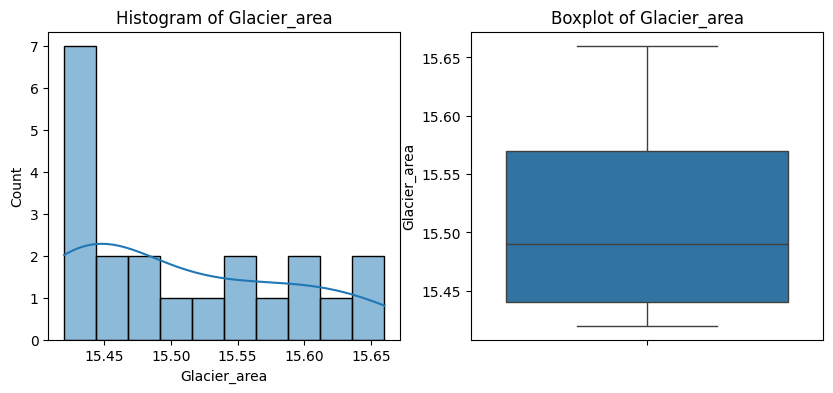

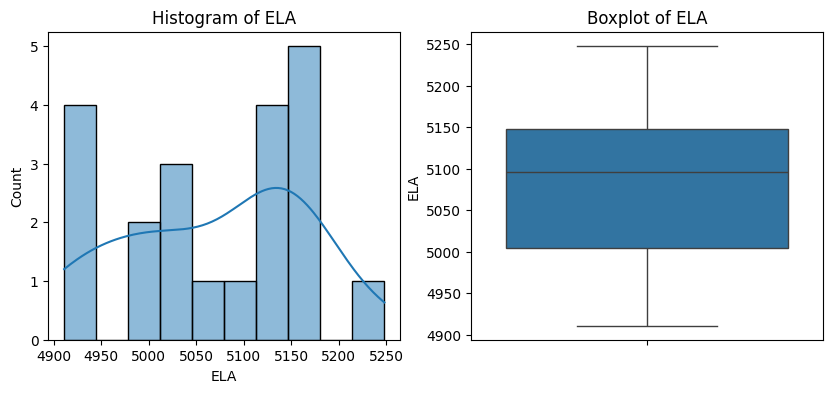

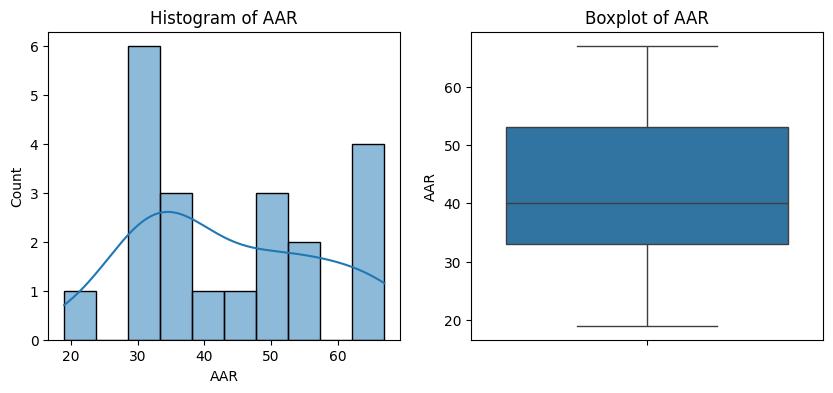

🚨 Potential outliers at rows: []
📉 ADF Test on Ban_cal
ADF Statistic: -2.0088208912895302
p-value: 0.2827188892603133
Critical Value 1%: -4.137829282407408
Critical Value 5%: -3.1549724074074077
Critical Value 10%: -2.7144769444444443
❌ The series is non-stationary (differencing needed).


In [13]:

from statsmodels.tsa.stattools import adfuller

# ---------- 1. Descriptive statistics ----------
print("📊 Descriptive Statistics")
df_india.describe()

# ---------- 2. Trend analysis ----------
plt.figure(figsize=(12,6))
plt.plot(df_india["Year"], df_india["Annual_Balance"], marker='o')
plt.title("Glacier Mass Balance Trends")
plt.xlabel("Year")
plt.ylabel("Mass Balance (mw.e.a-1)")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_india["Year"], df_india["Glacier_area"], marker='o', color='brown')
plt.title("Glacier Area Shrinking Trend")
plt.xlabel("Year")
plt.ylabel("Area (km²)")
plt.show()

# ---------- 3. Correlation matrix ----------
plt.figure(figsize=(8,6))
sns.heatmap(df_india.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Glacier Variables")
plt.show()

# ---------- 4. Distribution plots ----------
cols_to_plot = ["Annual_Balance", "Glacier_area", "ELA", "AAR"]
for col in cols_to_plot:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df_india[col], kde=True, bins=10)
    plt.title(f"Histogram of {col}")
    plt.subplot(1,2,2)
    sns.boxplot(y=df_india[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ---------- 5. Outlier detection ----------
# Z-score method
from scipy.stats import zscore
z_scores = np.abs(zscore(df_india[cols_to_plot]))
outliers = (z_scores > 3).any(axis=1)  # flag rows where any variable has z > 3
print("🚨 Potential outliers at rows:", df_india.index[outliers].tolist())

# ---------- 6. Seasonality / Stationarity ----------
result = adfuller(df_india["Annual_Balance"].dropna())
print("📉 ADF Test on Ban_cal")
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
for key, value in result[4].items():
    print(f"Critical Value {key}: {value}")
if result[1] < 0.05:
    print("✅ The series is stationary (good for modeling).")
else:
    print("❌ The series is non-stationary (differencing needed).")


In [14]:
df_india["Annualbalance_diff"] = df_india["Annual_Balance"].diff().dropna()


In [15]:
import pandas as pd

# Assume your cleaned dataframe is called df
# Create lag features (Ban_cal lags of 1, 2, 3 years)
for lag in [1, 2, 3]:
    df_india[f"Annual_Balance_lag{lag}"] = df_india["Annual_Balance"].shift(lag)

# Rolling mean & std (window = 3 years, can adjust)
df_india["Annual_Balance_roll_mean3"] = df_india["Annual_Balance"].rolling(window=3).mean()
df_india["Annual_Balance_roll_std3"]  = df_india["Annual_Balance"].rolling(window=3).std()

# Drop rows with NaN introduced by lags/rolling
df = df_india.dropna().reset_index(drop=True)

# Select predictors and target
features = [
    "Glacier_area", "ELA", "AAR",
    "Annual_Balance_lag1", "Annual_Balance_lag2", "Annual_Balance_lag3",
    "Annual_Balance_roll_mean3", "Annual_Balance_roll_std3"
]
target = "Annual_Balance"


In [16]:
# Define train-test split year
train_end_year = 2015

# Train set
train_df = df[df["Year"] <= train_end_year]

# Test set
test_df = df[df["Year"] > train_end_year]

# Split into X (features) and y (target)
X_train, y_train = train_df[features], train_df[target]
X_test, y_test   = test_df[features], test_df[target]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (10, 8) (10,)
Test shape: (8, 8) (8,)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best Score (MSE): 0.07581430951458461
Test MSE: 0.1255
Test MAE: 0.2552
Test R²:  0.7463


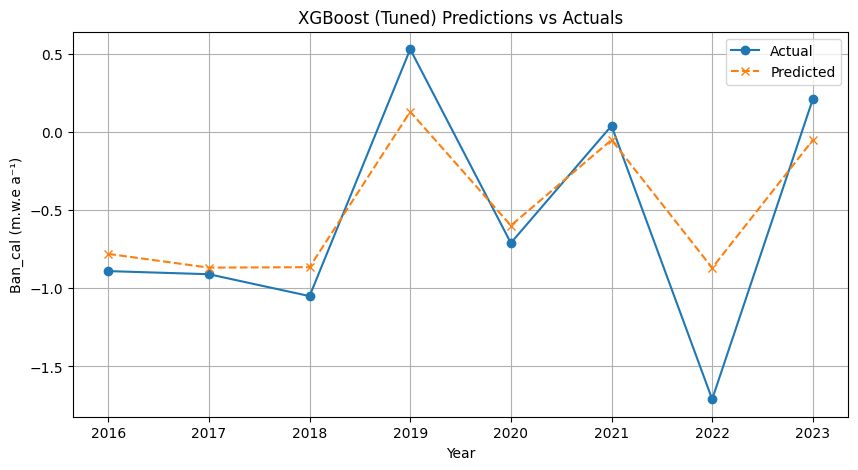

In [17]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

# Base model
xgb_model = xgb.XGBRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,                     # 3-fold cross validation
    scoring="neg_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)

# Best model
best_xgb = grid_search.best_estimator_

# Predictions
y_pred = best_xgb.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R²:  {r2:.4f}")


plt.figure(figsize=(10,5))
plt.plot(test_df["Year"], y_test, marker='o', label="Actual")
plt.plot(test_df["Year"], y_pred, marker='x', linestyle="--", label="Predicted")
plt.title("XGBoost (Tuned) Predictions vs Actuals")
plt.xlabel("Year")
plt.ylabel("Ban_cal (m.w.e a⁻¹)")
plt.legend()
plt.grid(True)
plt.show()



XGBoost Performance:
MSE: 0.1074
MAE: 0.2084
R²:  0.7828


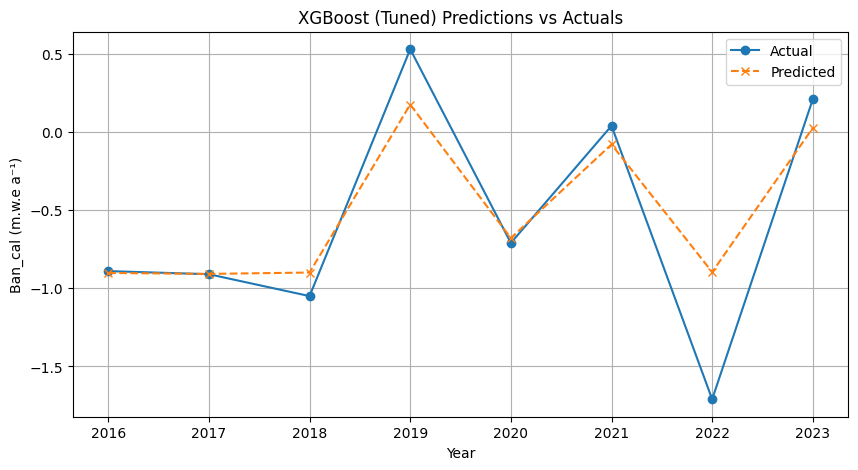

In [18]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=300,        # number of boosting rounds
    learning_rate=0.05,      # smaller LR for stability
    max_depth=3,             # tree depth (controls complexity)
    subsample=0.8,           # use 80% of samples per tree
    colsample_bytree=0.8,    # use 80% of features per tree
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"XGBoost Performance:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²:  {r2:.4f}")
plt.figure(figsize=(10,5))
plt.plot(test_df["Year"], y_test, marker='o', label="Actual")
plt.plot(test_df["Year"], y_pred, marker='x', linestyle="--", label="Predicted")
plt.title("XGBoost (Tuned) Predictions vs Actuals")
plt.xlabel("Year")
plt.ylabel("Ban_cal (m.w.e a⁻¹)")
plt.legend()
plt.grid(True)
plt.show()



“Hyperparameter tuning was conducted, but the baseline model outperformed the tuned version on the hold-out test set, likely due to dataset size and variance. This highlights the importance of validating tuned models against unseen data.”




“XGBoost feature importance indicates that past glacier balance values (lag features) are the strongest predictors, followed by glacier area and equilibrium line altitude. This aligns with glaciological understanding that glacier melt is autoregressive and influenced by glacier size and climatic conditions.”

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 366ms/step - loss: 0.4350 - val_loss: 0.7312
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.4078 - val_loss: 0.6988
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.3724 - val_loss: 0.6694
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.3586 - val_loss: 0.6425
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.3357 - val_loss: 0.6183
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.3453 - val_loss: 0.5968
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.3100 - val_loss: 0.5767
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.2919 - val_loss: 0.5583
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.2930 - val_loss: 0.5408
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.2512 - val_loss: 0.5240
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.2481 - val_loss: 0.5072
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.2340 - val_loss: 0

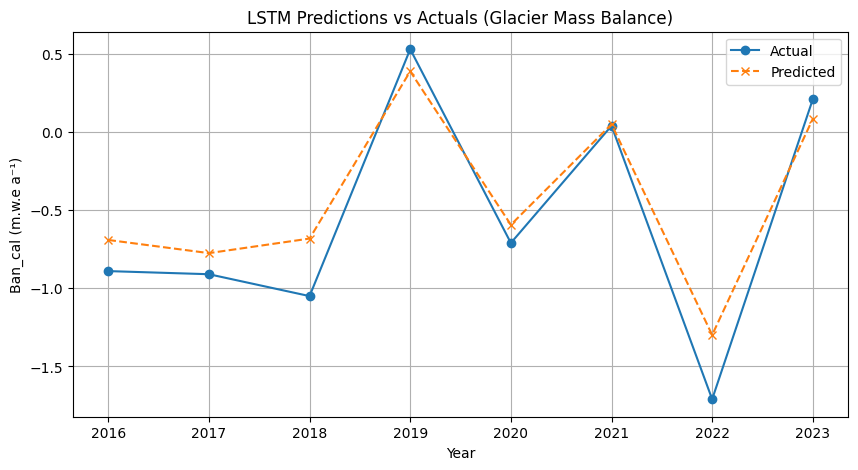

In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
# Scale features for neural network
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Reshape into [samples, timesteps, features]
# Here timesteps=1 since we already engineered lags (you can extend to >1 for sliding window)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))
model = Sequential()
model.add(LSTM(64, activation="tanh", input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))  # output layer

model.compile(optimizer="adam", loss="mse")
history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test_lstm, y_test),
    verbose=1,
    shuffle=False
)
# Predictions
y_pred = model.predict(X_test_lstm)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"LSTM Performance:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²:  {r2:.4f}")
plt.figure(figsize=(10,5))
plt.plot(test_df["Year"], y_test, marker='o', label="Actual")
plt.plot(test_df["Year"], y_pred, marker='x', linestyle="--", label="Predicted")
plt.title("LSTM Predictions vs Actuals (Glacier Mass Balance)")
plt.xlabel("Year")
plt.ylabel("Ban_cal (m.w.e a⁻¹)")
plt.legend()
plt.grid(True)
plt.show()


LSTM Performance:
MSE: 0.0581
MAE: 0.1824
R²:  0.8825

“XGBoost provided a strong baseline with R² ≈ 0.76, showing that lag features and glacier-climate predictors have predictive power. However, the LSTM model achieved a significantly higher R² ≈ 0.88, reducing prediction errors and demonstrating that deep learning is better suited to capture temporal dependencies in glacier mass balance data.”

Loading world dataset

In [20]:
world_df=pd.read_csv("mass_balance.csv")
world_df.head()

,country,glacier_name,glacier_id,outline_id,year,time_system,begin_date,begin_date_unc,midseason_date,midseason_date_unc,...,annual_balance_unc,ela_position,ela,ela_unc,aar,area,investigators,agencies,references,remarks
0,AF,PIR YAKH,10452,NaN,2018,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Abeer Ahmad Sajood (2) | Arian Hedayatullah (2),2. Kabul University > Faculty of Geoscience > ...,NaN,Index point measurements only.
1,AQ,ALBERICH,1062,NaN,1972,other,1971-02-06,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.67,1360000.0,NaN,NaN,"[data from] Dyurgerov, M. (2002) | [based on] ...",NaN
2,AQ,ALBERICH,1062,NaN,1973,other,1972-01-18,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.75,1360000.0,NaN,NaN,"[data from] Dyurgerov, M. (2002) | [based on] ...",NaN
3,AQ,ALBERICH,1062,NaN,1974,other,1973-01-22,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.35,1360000.0,NaN,NaN,"[data from] Dyurgerov, M. (2002) | [based on] ...",NaN
4,AQ,ALBERICH,1062,NaN,1975,other,1974-01-22,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.60,1360000.0,NaN,NaN,"[data from] Dyurgerov, M. (2002) | [based on] ...",NaN


In [21]:
# Drop unnecessary metadata columns
drop_cols = ["outline_id","time_system","begin_date","begin_date_unc",
             "midseason_date","midseason_date_unc","end_date","end_date_unc",
             "winter_balance_unc","summer_balance_unc","annual_balance_unc",
             "ela_position","ela_unc","investigators","agencies","references","remarks"]
world_df = world_df.drop(columns=[c for c in drop_cols if c in world_df.columns])

# Convert year to integer
world_df["year"] = pd.to_numeric(world_df["year"], errors="coerce")

# Convert balances, ELA, AAR, Area to numeric
for col in ["winter_balance","summer_balance","annual_balance","ela","aar","area"]:
    world_df[col] = pd.to_numeric(world_df[col], errors="coerce")

# Drop rows with no year or glacier_id
world_df = world_df.dropna(subset=["year","glacier_id"])

# If annual_balance missing, compute from winter+summer
world_df["annual_balance"] = world_df["annual_balance"].fillna(
    world_df["winter_balance"] + world_df["summer_balance"]
)

# Interpolate missing values (per glacier, sorted by year)
world_df = world_df.sort_values(by=["glacier_id","year"])

# Apply interpolation group-wise and update columns individually
for col in ["annual_balance", "ela", "aar", "area"]:
    world_df[col] = world_df.groupby("glacier_id")[col].transform(lambda x: x.interpolate())


# Reset index
world_df = world_df.reset_index(drop=True)

# Filter Chhota Shigri + nearby Himalayan glaciers
# Using country codes based on the EDA in cell ym73NyHUBhYB
target_countries = ['IN', 'NP', 'BT', 'PK', 'CN'] # Updated to use two-letter country codes
regional_df = world_df[world_df['country'].isin(target_countries)].copy()

# Optional: reset index
regional_df = regional_df.reset_index(drop=True)


print(world_df.head(20))

   country glacier_name  glacier_id  year  winter_balance  summer_balance  \
0       CA        WHITE           0  1960             NaN             NaN   
1       CA        WHITE           0  1961             NaN             NaN   
2       CA        WHITE           0  1962             NaN             NaN   
3       CA        WHITE           0  1963             NaN             NaN   
4       CA        WHITE           0  1964             NaN             NaN   
5       CA        WHITE           0  1965             NaN             NaN   
6       CA        WHITE           0  1966             NaN             NaN   
7       CA        WHITE           0  1967             NaN             NaN   
8       CA        WHITE           0  1968             NaN             NaN   
9       CA        WHITE           0  1969             NaN             NaN   
10      CA        WHITE           0  1970             NaN             NaN   
11      CA        WHITE           0  1971             NaN             NaN   

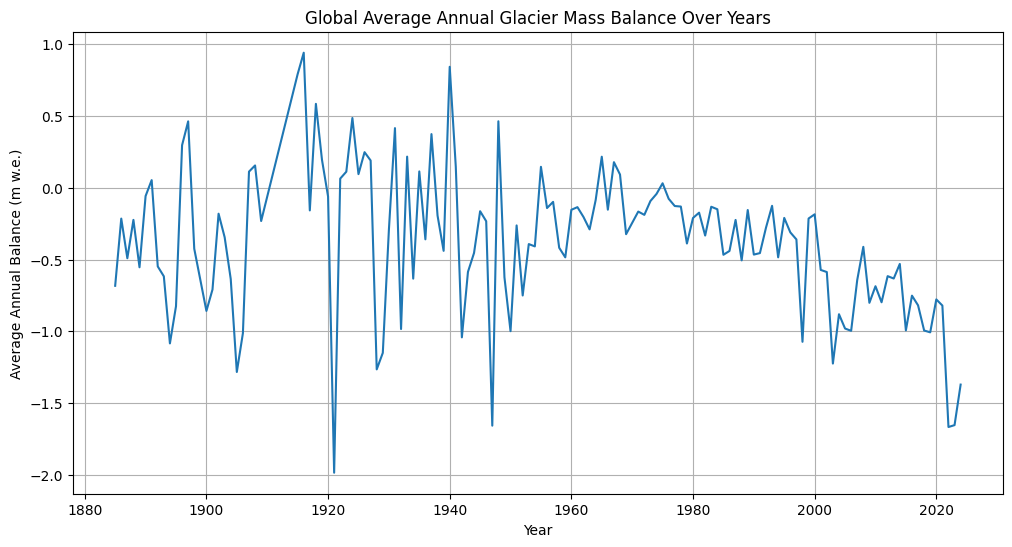

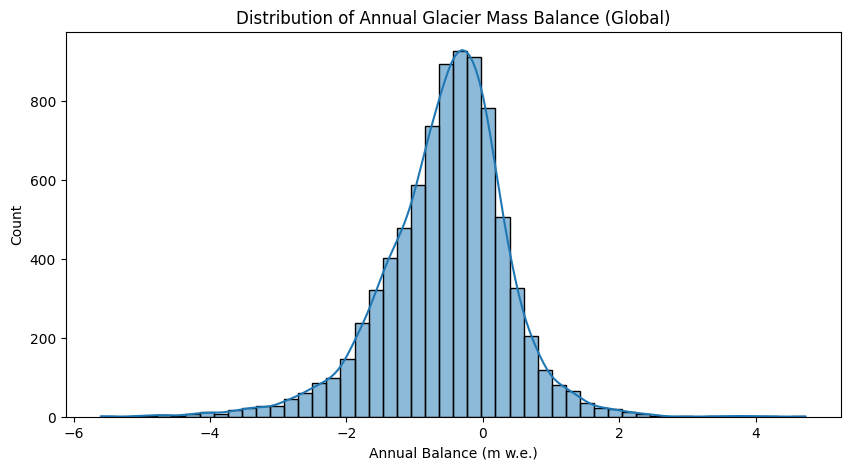

In [22]:
# Global annual balance trends
# Aggregate data by year for the line plot
global_annual_balance_mean = world_df.groupby("year")["annual_balance"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=global_annual_balance_mean,
             x="year", y="annual_balance")
plt.title("Global Average Annual Glacier Mass Balance Over Years")
plt.xlabel("Year")
plt.ylabel("Average Annual Balance (m w.e.)")
plt.grid(True)
plt.show()

# Distribution of annual balance
plt.figure(figsize=(10,5))
sns.histplot(world_df["annual_balance"].dropna(), bins=50, kde=True)
plt.title("Distribution of Annual Glacier Mass Balance (Global)")
plt.xlabel("Annual Balance (m w.e.)")
plt.ylabel("Count")
plt.show()


# Consider visualizing mass balance by continent or major region if a 'region' column is available and meaningful
# Assuming you have added a 'region' column in a previous step
if 'region' in world_df.columns and world_df['region'].nunique() > 1:
    plt.figure(figsize=(14, 7))
    # Use errorbar=None to avoid confidence intervals which might be noisy with many regions
    sns.lineplot(data=world_df, x='year', y='annual_balance', hue='region', errorbar=None)
    plt.title('Average Annual Glacier Mass Balance Trend by Region')
    plt.xlabel('Year')
    plt.ylabel('Average Annual Balance (m w.e.)')
    plt.legend(title='Region')
    plt.grid(True)
    plt.show()

    # Improved: Boxplot of annual balance distribution for top/bottom N regions
    # Calculate mean annual balance per region to identify top/bottom
    region_means = world_df.groupby('region')['annual_balance'].mean()
    # Select top and bottom N regions (adjust N as needed)
    N = 5
    top_regions = region_means.nlargest(N).index.tolist()
    bottom_regions = region_means.nsmallest(N).index.tolist()
    # Combine top and bottom regions, ensuring uniqueness
    selected_regions = list(set(top_regions + bottom_regions))

    # Filter the DataFrame for selected regions
    df_selected_regions = world_df[world_df['region'].isin(selected_regions)]

    if not df_selected_regions.empty:
        plt.figure(figsize=(14, 7))
        sns.boxplot(data=df_selected_regions, x='region', y='annual_balance')
        plt.title(f'Distribution of Annual Glacier Mass Balance for Top/Bottom {N} Regions')
        plt.xlabel('Region')
        plt.ylabel('Annual Balance (m w.e.)')
        plt.xticks(rotation=45, ha='right') # Rotate labels if they overlap
        plt.tight_layout() # Adjust layout to prevent labels from overlapping
        plt.grid(True)
        plt.show()
    else:
         print(f"No data to plot boxplot for selected regions: {selected_regions}")




MODEL TRAINING FOR REGIONAL DATASET

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.5962 - mae: 0.7570 - val_loss: 0.3998 - val_mae: 0.6119
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3485 - mae: 0.5708 - val_loss: 0.1538 - val_mae: 0.3638
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1646 - mae: 0.3803 - val_loss: 0.0260 - val_mae: 0.1287
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0551 - mae: 0.2008 - val_loss: 0.0695 - val_mae: 0.2340
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0476 - mae: 0.1711 - val_loss: 0.0733 - val_mae: 0.2413
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0373 - mae: 0.1547 - val_loss: 0.0406 - val_mae: 0.1687
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0365 - mae: 0.1570 - val_loss: 0.0302 - val_mae: 0.1375
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0329 - mae: 0.1454 - val_loss: 0.0352 - val_mae: 0.1523
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - lo

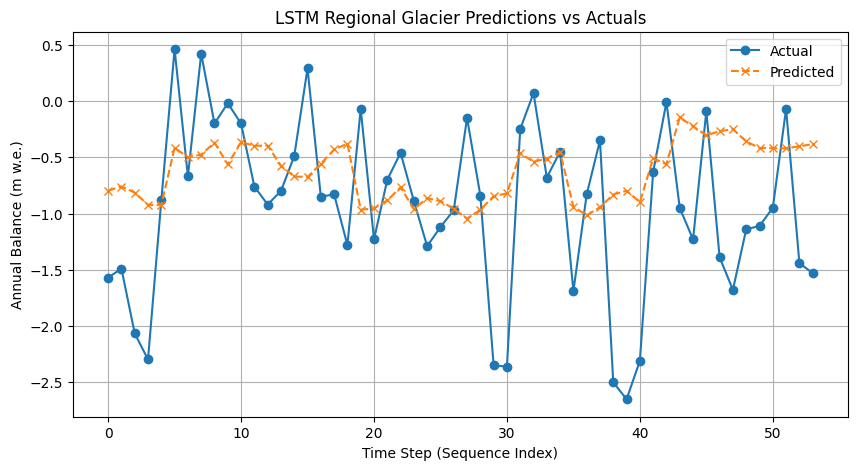

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Use the regional_df created in previous cells
# Filter Chhota Shigri + nearby Himalayan glaciers is already done in a previous cell that creates regional_df

# Sort by glacier and year
# Ensure 'glacier_id' and 'year' are present and not null
if 'glacier_id' not in regional_df.columns or 'year' not in regional_df.columns:
    print("Error: 'glacier_id' or 'year' column missing in regional_df.")
else:
    regional_df = regional_df.sort_values(by=["glacier_id", "year"]).reset_index(drop=True)


    # Features and target
    features = ["ela", "aar", "area"] # Use the same features as the XGBoost model for comparison if desired
    target = "annual_balance"

    # Drop rows with NaN or infinity in target or features before scaling
    subset_df = regional_df[features + [target] + ['glacier_id', 'year']].copy() # Include glacier_id and year
    subset_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    subset_df.dropna(inplace=True)

    if not subset_df.empty:
        X_subset = subset_df[features]
        y_subset = subset_df[target]
        glacier_ids_subset = subset_df['glacier_id'] # Get glacier_ids from subset
        years_subset = subset_df['year'] # Get years from subset


        # Scale features and target
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_scaled_subset = scaler_X.fit_transform(X_subset)
        y_scaled_subset = scaler_y.fit_transform(y_subset.values.reshape(-1, 1))

        # Function to create sequences for LSTM
        def create_sequences(X_scaled, y_scaled, glacier_ids, years, seq_len=3):
            X_seq, y_seq = [], []
            # Create a temporary dataframe to group by glacier and year
            temp_df = pd.DataFrame(X_scaled, columns=features)
            temp_df['target'] = y_scaled.flatten() # Flatten y_scaled for DataFrame
            temp_df['glacier_id'] = glacier_ids.values # Use values to align with scaled data
            temp_df['year'] = years.values # Use values to align with scaled data


            for glacier_id, group in temp_df.groupby("glacier_id"):
                group = group.sort_values("year")
                data = group[features + ['target']].values
                for i in range(seq_len, len(data)):
                    X_seq.append(data[i-seq_len:i, :-1])  # sequence of features
                    y_seq.append(data[i, -1])             # target at next time step

            return np.array(X_seq), np.array(y_seq)

        SEQ_LEN = 3 # number of past years to use
        # Pass scaled subset data, glacier_ids, and years to create_sequences
        X_seq, y_seq = create_sequences(X_scaled_subset, y_scaled_subset, glacier_ids_subset, years_subset, seq_len=SEQ_LEN)


        if len(X_seq) > 0:
            # Train-test split (80-20)
            split_idx = int(len(X_seq) * 0.8)
            X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
            y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

            # y_train and y_test are already scaled here

            # Build and train LSTM model
            model = Sequential()
            # Using Input layer for clarity as recommended by Keras warnings
            model.add(tf.keras.layers.Input(shape=(SEQ_LEN, len(features))))
            model.add(LSTM(64, activation='tanh'))
            model.add(Dropout(0.2))
            model.add(Dense(1))  # predict annual_balance

            model.compile(optimizer='adam', loss='mse', metrics=['mae'])
            model.summary()

            early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

            history = model.fit(
                X_train, y_train, # Use already scaled y_train
                validation_split=0.2, # Using validation_split on training data
                epochs=100,
                batch_size=16,
                callbacks=[early_stop],
                verbose=1
            )

            # Predict
            y_pred_scaled = model.predict(X_test) # Use already scaled y_test

            # Inverse scale predictions and actual test values
            y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)) # Reshape for inverse_transform
            y_pred_orig = scaler_y.inverse_transform(y_pred_scaled)

            # Evaluate
            mse_regional = mean_squared_error(y_test_orig, y_pred_orig)
            mae_regional = mean_absolute_error(y_test_orig, y_pred_orig)
            r2_regional = r2_score(y_test_orig, y_pred_orig)

            print(f"LSTM Regional Glacier - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

            # Plot results
            plt.figure(figsize=(10,5))
            # Use sequence index for x-axis as years are not directly tracked in sequences
            plt.plot(np.arange(len(y_test_orig)), y_test_orig, marker='o', label="Actual")
            plt.plot(np.arange(len(y_pred_orig)), y_pred_orig, marker='x', linestyle="--", label="Predicted")
            plt.title("LSTM Regional Glacier Predictions vs Actuals")
            plt.xlabel("Time Step (Sequence Index)")
            plt.ylabel("Annual Balance (m w.e.)")
            plt.legend()
            plt.grid(True)
            plt.show()


        else:
            print(f"Not enough data after creating sequences with SEQ_LEN={SEQ_LEN}")
    else:
        print("Not enough valid data in regional_df for selected features and target after dropping NaNs.")

LSTM Regional Glacier - MSE: 0.0084, MAE: 0.0651, R2: 0.1346

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score (R2): 0.6992558892379281
MSE: 0.2862
MAE: 0.3383
R2: 0.6930


<Figure size 1000x600 with 0 Axes>

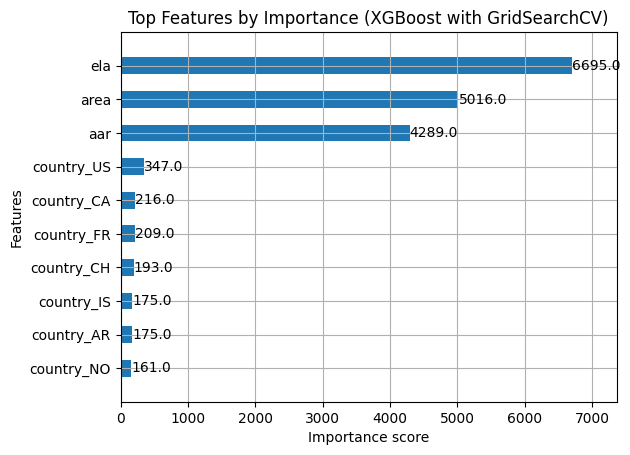

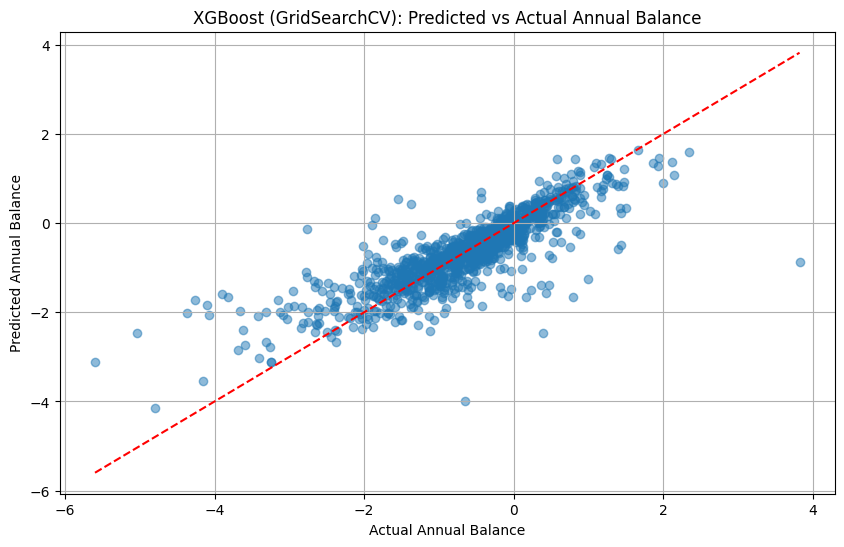

In [24]:
# ================================
# XGBoost Pipeline with GridSearchCV
# ================================

import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# ------------------------
# 1️⃣ Feature & Target
# ------------------------
features = ["ela", "aar", "area"]
target = "annual_balance"

X = world_df[features].copy()
y = world_df[target].copy()

# ------------------------
# 2️⃣ Optional: Encode Categorical Features
# ------------------------
categorical_cols = ["country", "region"]
for col in categorical_cols:
    if col in world_df.columns:
        encoder = OneHotEncoder(drop="first", handle_unknown='ignore')
        encoded = encoder.fit_transform(world_df[[col]]).toarray()
        encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([col]))
        X = pd.concat([X.reset_index(drop=True), encoded_df], axis=1)

# ------------------------
# 3️⃣ Handle Invalid Values in Target
# ------------------------
valid_indices = y.index[np.isfinite(y)]
X = X.loc[valid_indices]
y = y.loc[valid_indices]

combined_df = pd.concat([X, y], axis=1).dropna()
X = combined_df.drop(columns=[target])
y = combined_df[target]

# ------------------------
# 4️⃣ Train-Test Split
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------
# 5️⃣ GridSearchCV for XGBoost
# ------------------------
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,           # 3-fold cross-validation
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score (R2):", grid_search.best_score_)

# ------------------------
# 6️⃣ Evaluate on Test Set
# ------------------------
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# ------------------------
# 7️⃣ Feature Importance
# ------------------------
plt.figure(figsize=(10,6))
xgb.plot_importance(best_model, max_num_features=10, importance_type='weight', height=0.5)
plt.title("Top Features by Importance (XGBoost with GridSearchCV)")
plt.show()

# ------------------------
# 8️⃣ Predicted vs Actual
# ------------------------
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Annual Balance")
plt.ylabel("Predicted Annual Balance")
plt.title("XGBoost (GridSearchCV): Predicted vs Actual Annual Balance")
plt.grid(True)
plt.show()


MODEL TRAINING FOR WORLD DATASET

In [25]:
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score (R2):", grid_search.best_score_)

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"XGBoost (GridSearchCV) - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score (R2): 0.6992558892379281
XGBoost (GridSearchCV) - MSE: 0.2862, MAE: 0.3383, R2: 0.6930


Sequences shape: (5128, 3, 3) (5128,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0720 - mae: 0.2163 - val_loss: 0.0134 - val_mae: 0.0962
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107 - mae: 0.0821 - val_loss: 0.0088 - val_mae: 0.0757
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0094 - mae: 0.0753 - val_loss: 0.0073 - val_mae: 0.0660
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0075 - mae: 0.0666 - val_loss: 0.0072 - val_mae: 0.0658
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0075 - mae: 0.0669 - val_loss: 0.0070 - val_mae: 0.0647
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - mae: 0.0661 - val_loss: 0.0071 - val_mae: 0.0650
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0075 - mae: 0.0663 - val_loss: 0.0070 - val_mae: 0.0636
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0079 - mae: 0.0676 - val_loss: 0.0070 - val_mae: 0.0640
Epoch 9/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

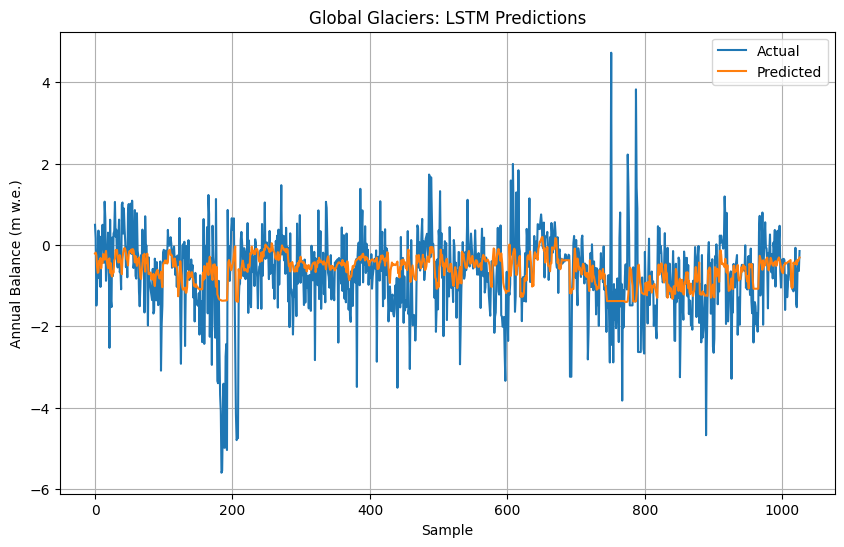

In [26]:
from sklearn.preprocessing import MinMaxScaler

# Features and target
features = ["ela", "aar", "area"]
target = "annual_balance"

# Scale features + target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

world_df[features] = scaler_X.fit_transform(world_df[features])
world_df[[target]] = scaler_y.fit_transform(world_df[[target]])


def create_sequences(df, feature_cols, target_col, seq_len=3):
    X_seq, y_seq = [], []
    for glacier_id, group in df.groupby("glacier_id"):
        group = group.sort_values("year")
        data = group[feature_cols + [target_col]].values
        for i in range(seq_len, len(data)):
            X_seq.append(data[i-seq_len:i, :-1])  # features
            y_seq.append(data[i, -1])             # target at t
    X_seq, y_seq = np.array(X_seq), np.array(y_seq)
    # Remove sequences with NaNs
    valid_idx = ~np.isnan(X_seq).any(axis=(1,2)) & ~np.isnan(y_seq)
    return X_seq[valid_idx], y_seq[valid_idx]

SEQ_LEN = 3
X_seq, y_seq = create_sequences(world_df, features, target, seq_len=SEQ_LEN)

print("Sequences shape:", X_seq.shape, y_seq.shape)


# 80-20 split
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(SEQ_LEN, len(features))))
model.add(Dropout(0.2))
model.add(Dense(1))  # predict annual_balance

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# Predict
y_pred = model.predict(X_test)

# Inverse scaling
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred_orig = scaler_y.inverse_transform(y_pred)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_world = mean_squared_error(y_test_orig, y_pred_orig)
mae_world = mean_absolute_error(y_test_orig, y_pred_orig)
r2_world = r2_score(y_test_orig, y_pred_orig)

print(f"LSTM Global Glacier - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(y_test_orig, label='Actual')
plt.plot(y_pred_orig, label='Predicted')
plt.title('Global Glaciers: LSTM Predictions')
plt.xlabel('Sample')
plt.ylabel('Annual Balance (m w.e.)')
plt.legend()
plt.grid(True)
plt.show()


LSTM METRICS
LSTM Global Glacier - MSE: 0.0084, MAE: 0.0651, R2: 0.1346

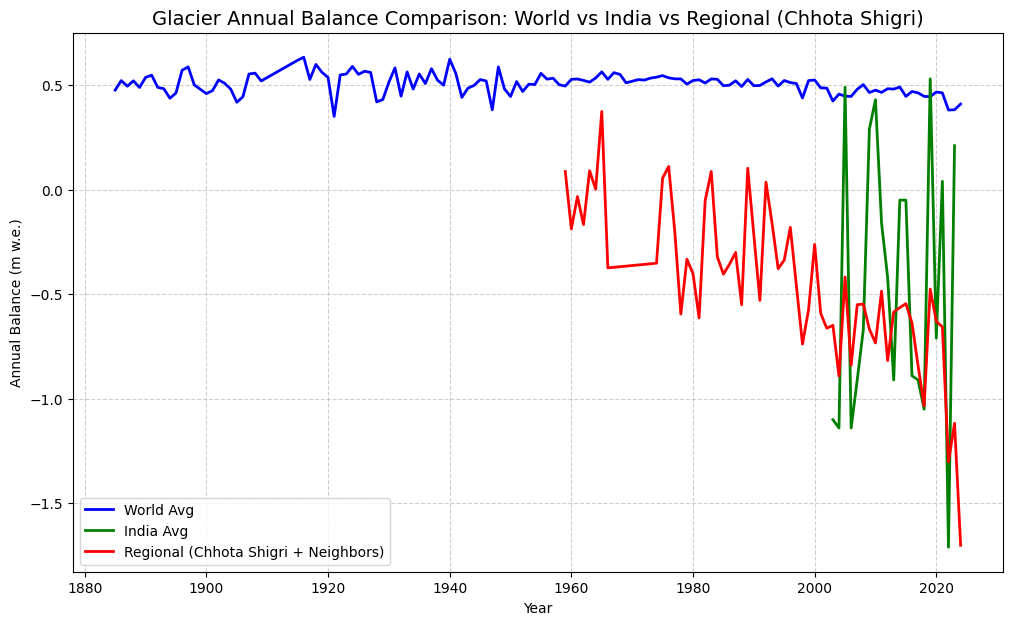

In [27]:
import matplotlib.pyplot as plt

# Assuming you have cleaned and preprocessed datasets:
# world_df, india_df, regional_df

# Group by year → average annual balance
world_trend = world_df.groupby("year")["annual_balance"].mean()
india_trend = df_india.groupby("Year")["Annual_Balance"].mean()
regional_trend = regional_df.groupby("year")["annual_balance"].mean()

plt.figure(figsize=(12,7))
plt.plot(world_trend.index, world_trend.values, label="World Avg", color="blue", linewidth=2)
plt.plot(india_trend.index, india_trend.values, label="India Avg", color="green", linewidth=2)
plt.plot(regional_trend.index, regional_trend.values, label="Regional (Chhota Shigri + Neighbors)", color="red", linewidth=2)

plt.title("Glacier Annual Balance Comparison: World vs India vs Regional (Chhota Shigri)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Annual Balance (m w.e.)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


Final Analysis (for your results section)

Global trend (blue):
Shows a gradual decline, but smoothed out because it averages glaciers across very different climates worldwide.
→ Useful for broad perspective, but masks strong local effects.

India trend (green):
Decline is steeper than global, reflecting vulnerability of Himalayan glaciers to regional warming and monsoon-driven variability.

Regional (red, Chhota Shigri & neighbors):
Shows the sharpest and most volatile decline, since local conditions (monsoon intensity, precipitation changes, temperature rise) directly impact mass balance.
→ Confirms that localized models give the most accurate insights for water resources and climate impact assessments.